# H&M Transaction Data: Product Recommendations 02
## Transform data and build a neural net model

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt

import os
import sys
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# data processing classes
from src.customer_features import CustomerFeatureEngineer
from src.product_features import ProductFeatureEngineer
from src.recommendation_training import RecommendationTrainingBuilder


## Load Processed Data

In [2]:
# Load data from parquet
data_path = Path("../data")
processed_data_path = data_path / 'processed' / 'product_recommendation'

with open(processed_data_path / 'X_train_base.pkl', 'rb') as f:
    X_train = pickle.load(f)
with open(processed_data_path / 'y_train_base.pkl', 'rb') as f:
    y_train = pickle.load(f)
with open(processed_data_path / 'X_val_base.pkl', 'rb') as f:
    X_val = pickle.load(f)
with open(processed_data_path / 'y_val_base.pkl', 'rb') as f:
    y_val = pickle.load(f)
with open(processed_data_path / 'X_test_base.pkl', 'rb') as f:
    X_test = pickle.load(f)
with open(processed_data_path / 'y_test_base.pkl', 'rb') as f:
    y_test = pickle.load(f)

print(f"{X_train.shape=}")
print(f"{y_train.shape=}")
print(f"{X_val.shape=}")
print(f"{y_val.shape=}")
print(f"{X_test.shape=}")
print(f"{y_test.shape=}")

X_train.shape=(83100, 36)
y_train.shape=(83100,)
X_val.shape=(90432, 36)
y_val.shape=(90432,)
X_test.shape=(85764, 36)
y_test.shape=(85764,)


In [3]:
# Check what you loaded
print(f"X_train type: {type(X_train)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_train memory: {X_train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nData types:")
print(X_train.dtypes)

X_train type: <class 'pandas.core.frame.DataFrame'>
X_train shape: (83100, 36)
X_train memory: 11.81 MB

Data types:
garment_Trousers Denim                      bool
garment_Skirts                              bool
avg_transaction_value                    float64
garment_Special Offers                      bool
max_price                                float64
garment_Dresses Ladies                      bool
garment_Knitwear                            bool
garment_Socks and Tights                    bool
garment_Unknown                             bool
garment_Trousers                            bool
total_spent                              float64
garment_Blouses                             bool
garment_Shorts                              bool
garment_Woven/Jersey/Knitted mix Baby       bool
sales_last_7_days                          int64
garment_Outdoor                             bool
customer_price_std                       float64
garment_Dressed                             bool
c

## Feature Engineering and Scaling

### Log transform financial features

In [4]:
cols_to_log = ['avg_price', 'max_price', 'total_spent', 'min_price', 'num_purchases', 'sales_last_7_days', 'sales_last_30_days']

for price_feature in cols_to_log:
    X_train[f"log_{price_feature}"] = np.log1p(X_train[price_feature])
    X_train.drop(columns=[price_feature], inplace=True)
    X_val[f"log_{price_feature}"] = np.log1p(X_val[price_feature])
    X_val.drop(columns=[price_feature], inplace=True)
    X_test[f"log_{price_feature}"] = np.log1p(X_test[price_feature])
    X_test.drop(columns=[price_feature], inplace=True)
    

In [5]:
# Avg days between purchases is filled with 999 for inactive customers
# Create an inactive flag to coincide with it

X_train['inactive'] = (X_train['avg_days_between_purchases'] == 999).astype(int)
X_val['inactive'] = (X_val['avg_days_between_purchases'] == 999).astype(int)
X_test['inactive'] = (X_test['avg_days_between_purchases'] == 999).astype(int)

### Standard Scaler

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"X_train before scaling - mean: {X_train.mean().mean():.2f}, std: {X_train.std().mean():.2f}")
print(f"X_train after scaling - mean: {X_train_scaled.mean():.2f}, std: {X_train_scaled.std():.2f}")

X_train before scaling - mean: 24.33, std: 19.02
X_train after scaling - mean: 0.00, std: 1.00


## Description of Data

### Correlation Matrix

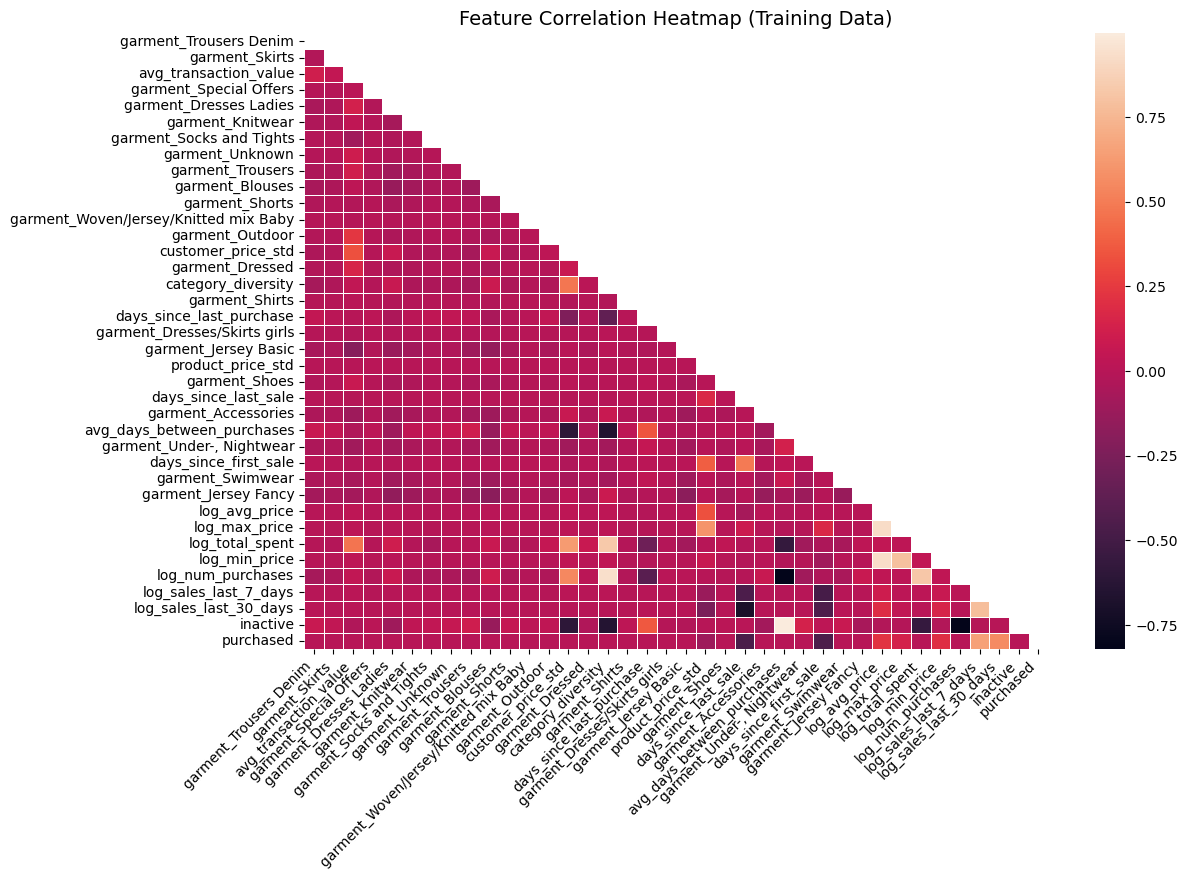

In [7]:
corr = pd.concat([X_train, y_train], axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))
ax = sns.heatmap(corr,mask=mask,annot=False, linewidths=.5)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title('Feature Correlation Heatmap (Training Data)', fontsize=14)
plt.show()

### Distribution of price

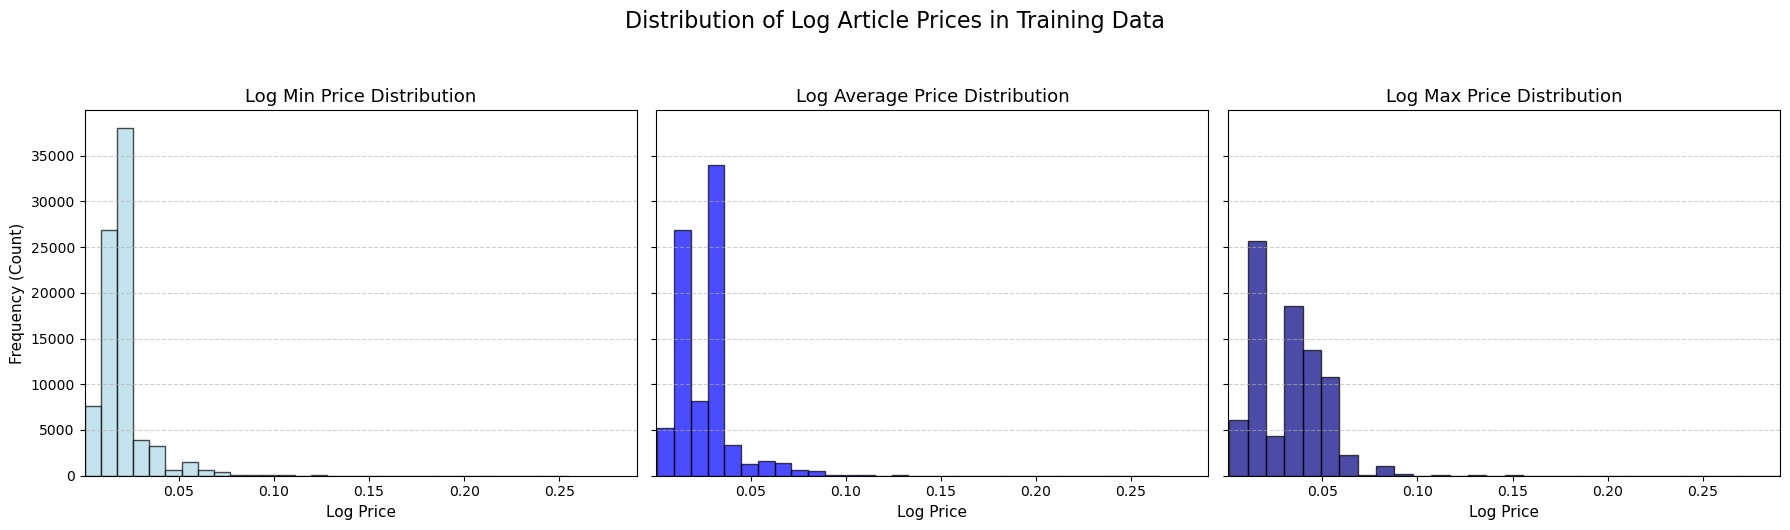

In [8]:
log_price_cols = ['log_min_price', 'log_avg_price', 'log_max_price']
X_train_prices = X_train[log_price_cols].copy()

x_min = X_train_prices.min().min()
x_max = X_train_prices.max().max()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
titles = ['Log Min Price Distribution', 'Log Average Price Distribution', 'Log Max Price Distribution']
colors = ['lightblue', 'blue', 'navy']

for i in range(3):
    axes[i].hist(X_train_prices[log_price_cols[i]], bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(titles[i], fontsize=13)
    axes[i].set_xlabel("Log Price", fontsize=11)
    if i == 0:
        axes[i].set_ylabel("Frequency (Count)", fontsize=11)
    axes[i].set_xlim(x_min, x_max)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)
fig.suptitle('Distribution of Log Article Prices in Training Data', fontsize=16, y=1.05)

plt.tight_layout()
plt.show()

### Customer Behavior Features

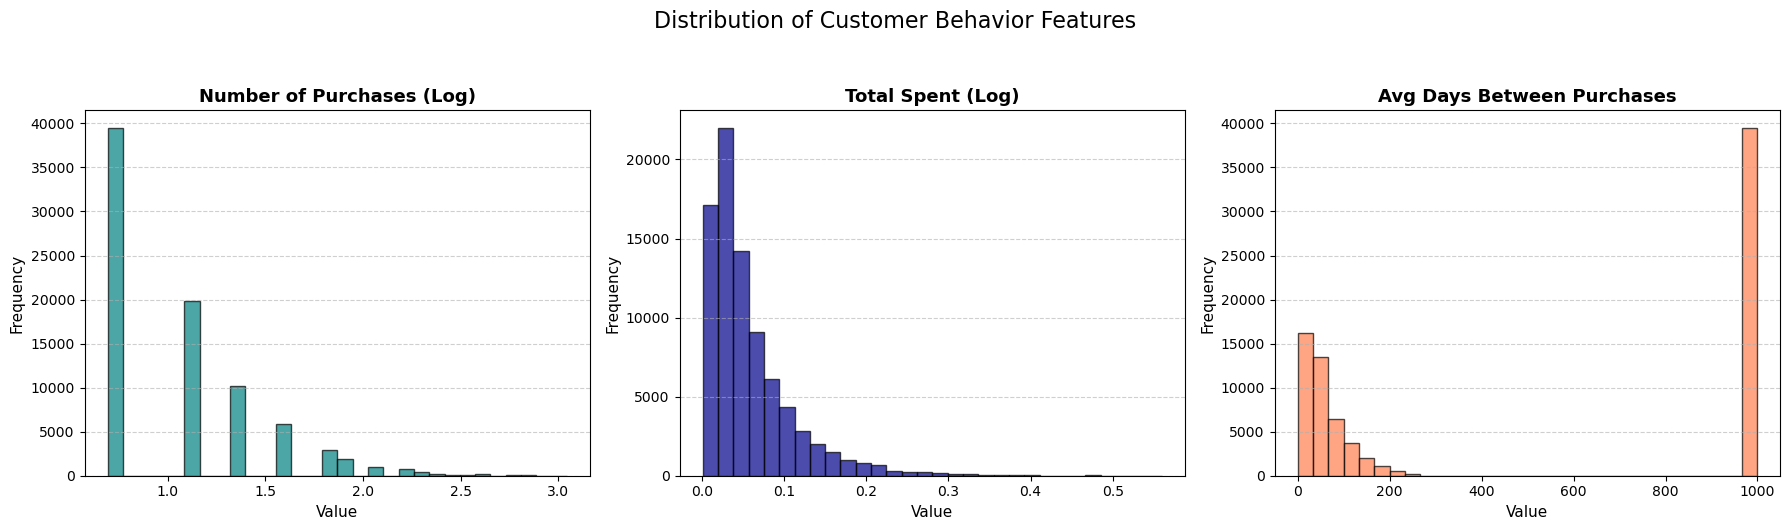

In [9]:
cols = ['log_num_purchases', 'log_total_spent', 'avg_days_between_purchases']
titles = ['Number of Purchases (Log)', 'Total Spent (Log)', 'Avg Days Between Purchases']
colors = ['teal', 'darkblue', 'coral']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i in range(3):
    axes[i].hist(X_train[cols[i]], bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(titles[i], fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Value", fontsize=11)
    axes[i].set_ylabel("Frequency", fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

fig.suptitle('Distribution of Customer Behavior Features', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Sales Distribution

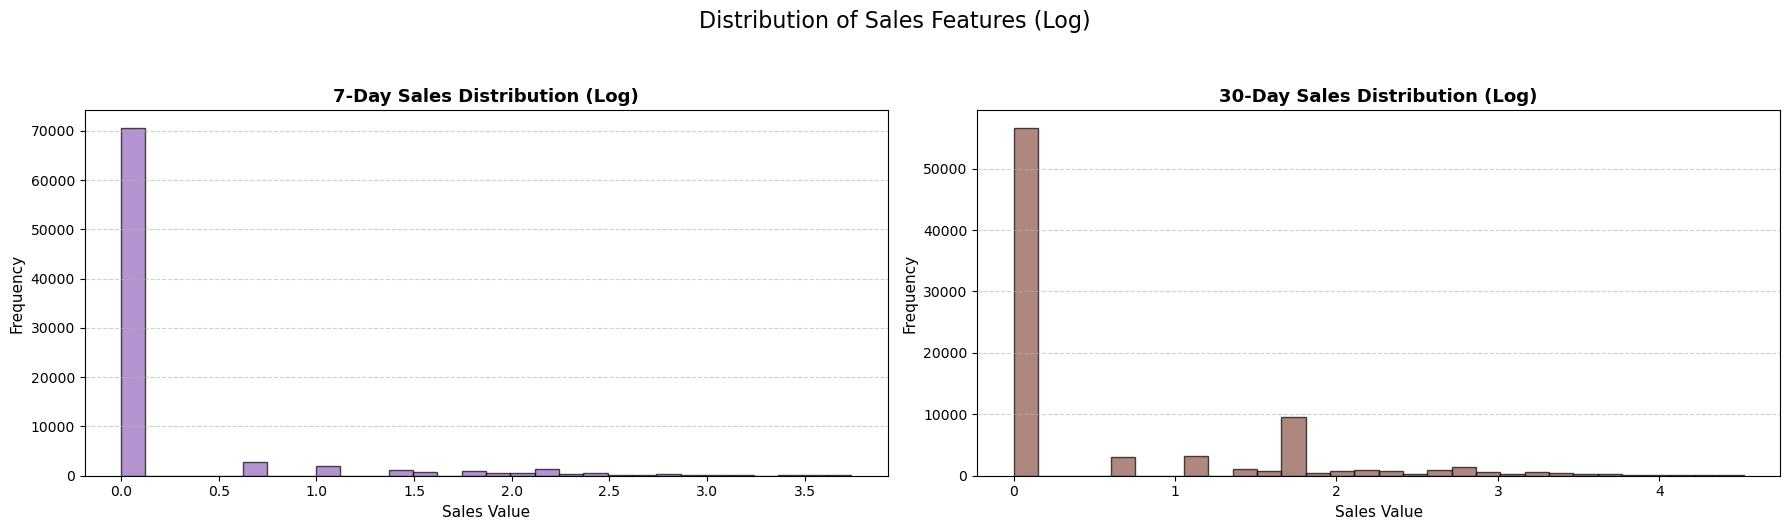

In [10]:
sales_cols = ['log_sales_last_7_days', 'log_sales_last_30_days']
titles = [ '7-Day Sales Distribution (Log)', '30-Day Sales Distribution (Log)']
colors = [ '#9467bd', '#8c564b']

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for i in range(2):
    axes[i].hist(X_train[sales_cols[i]], bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(titles[i], fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Sales Value", fontsize=11)
    axes[i].set_ylabel("Frequency", fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

fig.suptitle('Distribution of Sales Features (Log)', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

In [45]:
base_path = "../data/"
articles_clean_df = pd.read_csv(base_path + "articles_hm_cleaned.csv")
customers_clean_df = pd.read_csv(base_path + "customer_hm_cleaned.csv")
transactions_clean_df = pd.read_csv(base_path + "transactions_hm_cleaned.csv")

### Repeat Customer Analysis

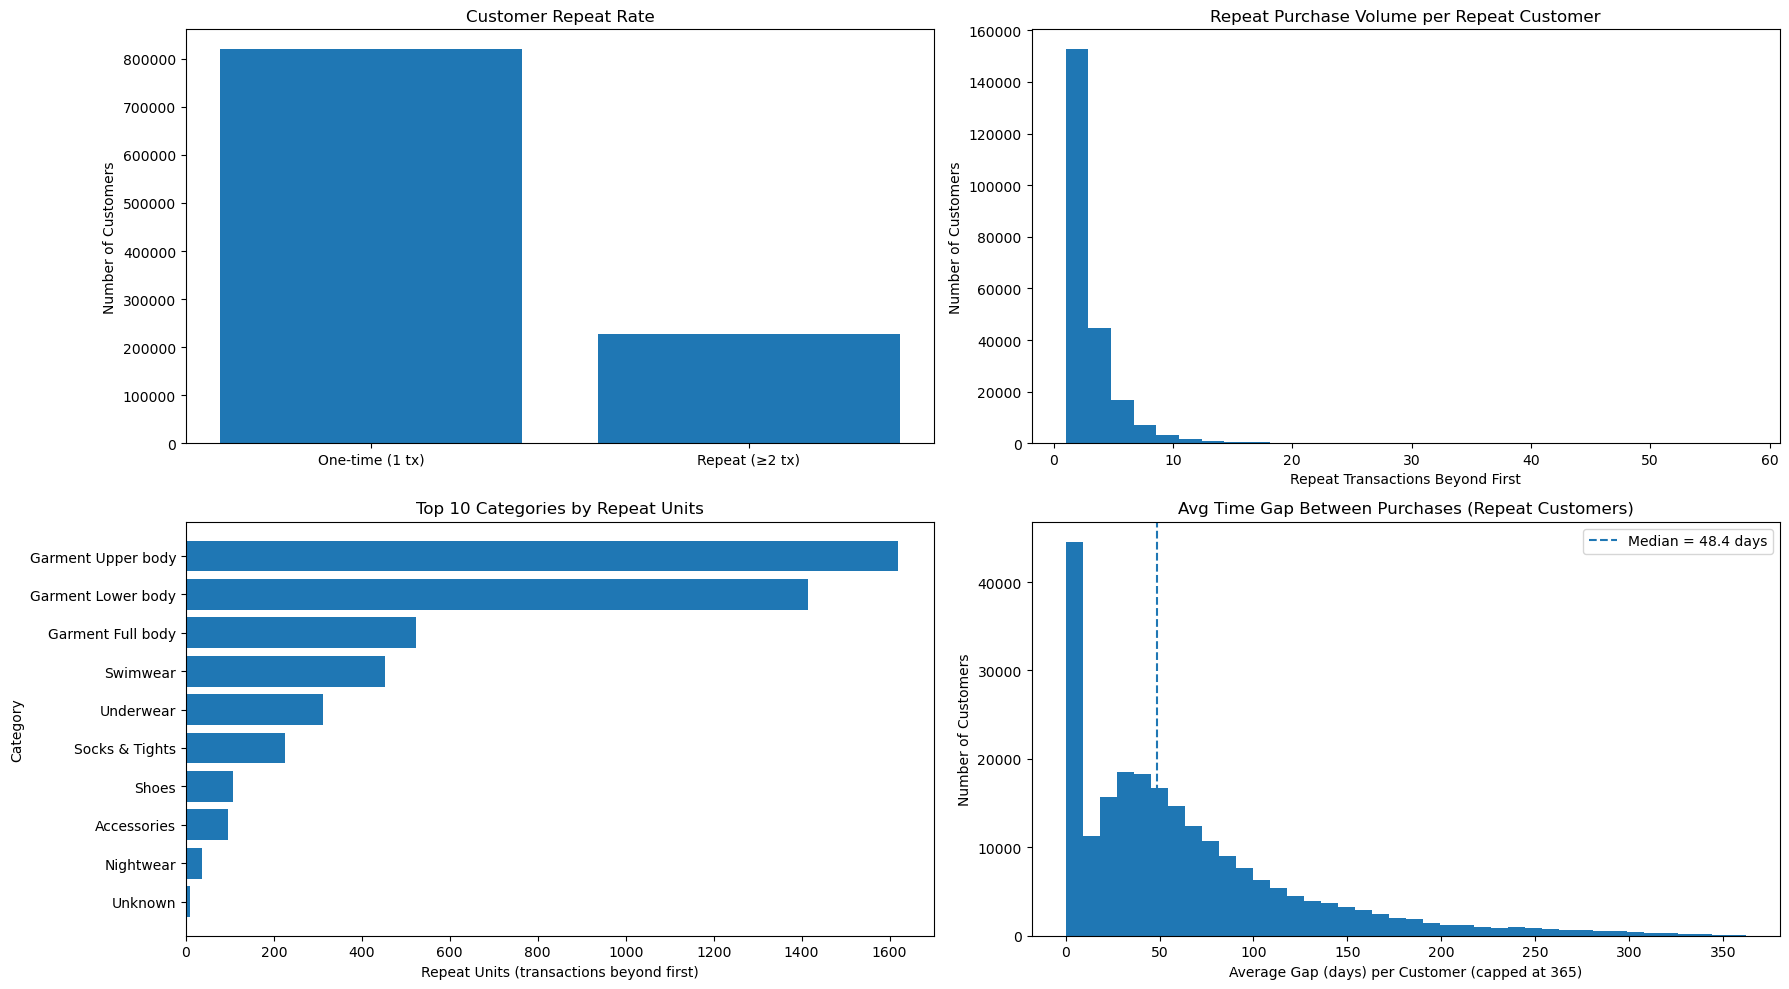

In [52]:
import matplotlib.pyplot as plt


def style_ax(ax, title, xlabel=None, ylabel=None):
    ax.set_title(title)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)


one_time_customers = n_all_customers - n_repeat_customers

repeat_rate_vals = [one_time_customers, n_repeat_customers]
repeat_rate_labels = ["One-time (1 tx)", "Repeat (≥2 tx)"]

gaps = repeat_gap_per_customer.dropna()
median_gap = gaps.median() if len(gaps) else None

top_k = 10
top_cat_repeat = cat_repeat.head(top_k).sort_values() 

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# (1) Repeat rate bar
axes[0, 0].bar(repeat_rate_labels, repeat_rate_vals)
style_ax(axes[0, 0], "Customer Repeat Rate", ylabel="Number of Customers")
axes[0, 0].tick_params(axis="x", rotation=0)

# (2) Repeat volume distribution
axes[0, 1].hist(repeat_volume_per_customer, bins=30)
style_ax(
    axes[0, 1],
    "Repeat Purchase Volume per Repeat Customer",
    xlabel="Repeat Transactions Beyond First",
    ylabel="Number of Customers",
)

# (3) Top repeat categories (KPI #3)
axes[1, 0].barh(top_cat_repeat.index.astype(str), top_cat_repeat.values)
style_ax(
    axes[1, 0],
    f"Top {top_k} Categories by Repeat Units",
    xlabel="Repeat Units (transactions beyond first)",
    ylabel="Category",
)

# (4) Average time gap distribution (KPI #4)
axes[1, 1].hist(gaps.clip(upper=365), bins=40)
style_ax(
    axes[1, 1],
    "Avg Time Gap Between Purchases (Repeat Customers)",
    xlabel="Average Gap (days) per Customer (capped at 365)",
    ylabel="Number of Customers",
)

if median_gap is not None:
    axes[1, 1].axvline(median_gap, linestyle="--", label=f"Median = {median_gap:.1f} days")
    axes[1, 1].legend()

plt.tight_layout()
plt.show()

### Age-bin normalized category preference:

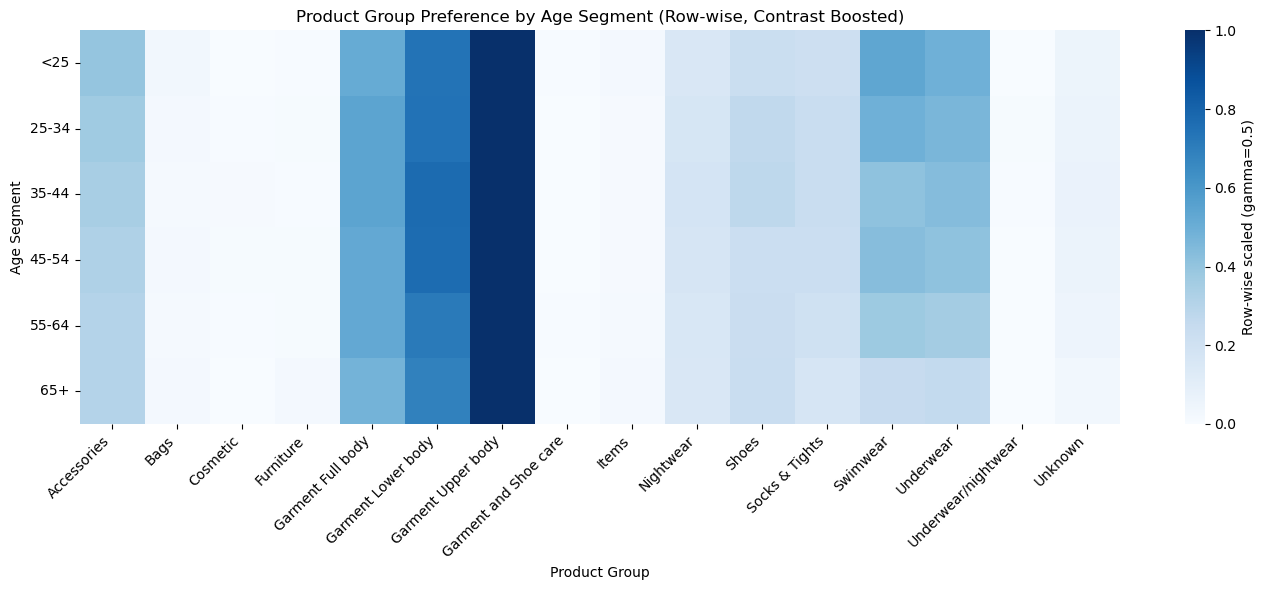

In [47]:
cust_tx = transactions_clean_df.merge(
    customers_clean_df[["customer_id", "age"]], on="customer_id", how="left"
).merge(
    articles_clean_df[["article_id", "product_group_name"]], on="article_id", how="left"
)

cust_tx["age_bin"] = pd.cut(
    cust_tx["age"],
    bins=[0, 24, 34, 44, 54, 64, 120],
    labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
)

row_min = age_group_pref.min(axis=1)
row_max = age_group_pref.max(axis=1)
row_scaled = age_group_pref.sub(row_min, axis=0).div((row_max - row_min), axis=0).fillna(0)

# Contrast boost: gamma < 1 makes mid/high values darker (more separation)
gamma = 0.5   # try 0.4 ~ 0.8
row_scaled_contrast = row_scaled ** gamma

plt.figure(figsize=(14,6))
sns.heatmap(
    row_scaled_contrast,
    cmap="Blues",
    vmin=0, vmax=1,
    cbar_kws={"label": f"Row-wise scaled (gamma={gamma})"}
)

plt.title("Product Group Preference by Age Segment (Row-wise, Contrast Boosted)")
plt.xlabel("Product Group")
plt.ylabel("Age Segment")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Model building

Build a neural net model with variable number of hidden layers.

- num_features: number of features in dataset
- hidden_layer_sizes: variable array of nodes in hidden layers of neural net
- learning_rate: hyperparameter learning rate
- activation: activation function used within hidden layers
- optimizer: Adam or SGD optimizer

Uses sigmoid activation for the final layer. Reports accuracy.

In [11]:
class MajorityClassifier:  
    def fit(self, X, y):
        y_actual = self._y_actual(y)
        
        self.majority = y_actual.mode()[0]
        self.majority_probability = (y_actual == self.majority).mean()
        self.class_probabilities = y_actual.value_counts(normalize=True).sort_index()
        self.classes = self.class_probabilities.index.to_list()

    def predict(self, X):
        return np.full(len(X), self.majority)

    def evaluate(self, X, y):
        prediction = self.predict(X)
        actual = self._y_actual(y)
        accuracy = (prediction == actual).mean()
        return {'accuracy': accuracy}

    def log_loss(self, y):
        y_actual = self._y_actual(y)
        
        predicted_probabilities = np.tile(self.class_probabilities.values, (len(y), 1))
        
        y_one_hot = np.zeros((len(y), len(self.classes)))
        for i, val in enumerate(y_actual):
            class_idx = self.classes.index(val)
            y_one_hot[i, class_idx] = 1 
        
        log_p = np.log(np.clip(predicted_probabilities, 1e-15, 1))
        return -np.sum(y_one_hot * log_p) / len(y)
    
    def _y_actual(self, y):
        return y.iloc[:, 0] if isinstance(y, pd.DataFrame) else y

In [12]:
baseline = MajorityClassifier()
baseline.fit(X_train_scaled, y_train)

print(f"Baseline predictions: Always predict {baseline.majority}")
print(f"Training accuracy: {baseline.evaluate(X_train_scaled, y_train)['accuracy']:.4f}")
print(f"Training loss: {baseline.log_loss(y_train):.4f}")

print(f"Validation accuracy: {baseline.evaluate(X_val_scaled, y_val)['accuracy']:.4f}")
print(f"Validation loss: {baseline.log_loss(y_val):.4f}")

Baseline predictions: Always predict 0
Training accuracy: 0.8333
Training loss: 0.4506
Validation accuracy: 0.8333
Validation loss: 0.4506


In [14]:
def build_recommendation_model(num_features,
                                hidden_layer_sizes=[512],
                                learning_rate=0.001,
                                activation='relu',
                                optimizer="Adam"):
    tf.keras.backend.clear_session()
    tf.random.set_seed(67)

    model = tf.keras.Sequential()
    for i, layer_units in enumerate(hidden_layer_sizes):
        if i == 0:
            layer = tf.keras.layers.Dense(
                units=layer_units,
                input_shape=(num_features,),
                use_bias=True,
                activation=activation,
                kernel_initializer=tf.initializers.RandomNormal(stddev=0.01),
                bias_initializer=tf.initializers.RandomNormal(stddev=0.01)
            )
        else:
            layer = tf.keras.layers.Dense(
                units=layer_units,
                use_bias=True,
                activation=activation,
                kernel_initializer=tf.initializers.RandomNormal(stddev=0.01),
                bias_initializer=tf.initializers.RandomNormal(stddev=0.01)
            )
        model.add(layer)
    
    model.add(tf.keras.layers.Dense(
        units=1,
        use_bias=True,
        activation='sigmoid',
        kernel_initializer=tf.initializers.RandomNormal(stddev=0.01),
        bias_initializer=tf.initializers.RandomNormal(stddev=0.01)
        )
    )

    if optimizer == "SGD":
        keras_optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer == "Adam":
        keras_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        keras_optimizer = optimizer

    model.compile(
        loss=tf.keras.losses.BinaryCrossentropy(),
        optimizer=keras_optimizer,
        metrics=['accuracy']
    )
    
    return model

In [27]:

model = build_recommendation_model(X_train_scaled.shape[1],
                                    hidden_layer_sizes=[128,32],
                                    learning_rate=0.00001,
                                    activation='relu',
                                    optimizer="Adam")
model.summary()
history = model.fit(X_train_scaled, y_train,
                    validation_data=(X_val_scaled, y_val),
                    epochs=8,
                    batch_size=16,
                    verbose=1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,025 (35.25 KB)

 Trainable params: 9,025 (35.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
5194/5194 ━━━━━━━━━━━━━━━━━━━━ 4s 666us/step - accuracy: 0.7979 - loss: 0.5125 - val_accuracy: 0.8557 - val_loss: 0.2960
Epoch 2/8
5194/5194 ━━━━━━━━━━━━━━━━━━━━ 3s 649us/step - accuracy: 0.8903 - loss: 0.2764 - val_accuracy: 0.9162 - val_loss: 0.2342
Epoch 3/8
5194/5194 ━━━━━━━━━━━━━━━━━━━━ 3s 627us/step - accuracy: 0.9148 - loss: 0.2497 - val_accuracy: 0.9306 - val_loss: 0.2097
Epoch 4/8
5194/5194 ━━━━━━━━━━━━━━━━━━━━ 3s 628us/step - accuracy: 0.9207 - loss: 0.2316 - val_accuracy: 0.9350 - val_loss: 0.1927
Epoch 5/8
5194/5194 ━━━━━━━━━━━━━━━━━━━━ 3s 636us/step - accuracy: 0.9230 - loss: 0.2198 - val_accuracy: 0.9352 - val_loss: 0.1828
Epoch 6/8
5194/5194 ━━━━━━━━━━━━━━━━━━━━ 3s 634us/step - accuracy: 0.9247 - loss: 0.2130 - val_accuracy: 0.9357 - val_loss: 0.1778
Epoch 7/8
5194/5194 ━━━━━━━━━━━━━━━━━━━━ 3s 645us/step - accuracy: 0.9269 - loss: 0.2086 - val_accuracy: 0.9366 - val_loss: 0.1753
Epoch 8/8
5194/5194 ━━━━━━━━━━━━━━━━━━━━ 3s 641us/step - accuracy: 0.9282 - loss: 0

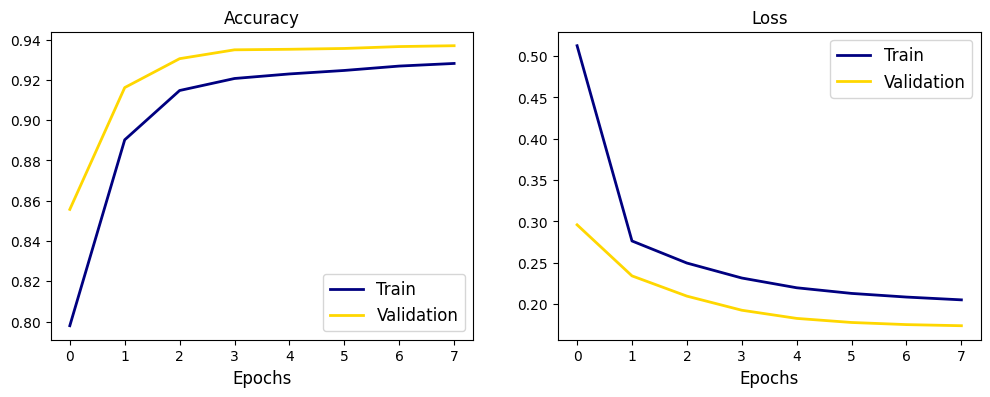

In [28]:
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(history.history['accuracy'], lw=2, color='navy')
plt.plot(history.history['val_accuracy'], lw=2, color='gold')
plt.legend(['Train', 'Validation'], fontsize=12)
ax.set_xlabel('Epochs', size=12)
ax.set_title('Accuracy', size=12)

ax = fig.add_subplot(1, 2, 2)
plt.plot(history.history['loss'], lw=2, color='navy')
plt.plot(history.history['val_loss'], lw=2, color='gold')
plt.legend(['Train', 'Validation'], fontsize=12)
ax.set_xlabel('Epochs', size=12)
ax.set_title('Loss', size=12)

plt.show()

## Test Data

In [29]:
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"\n{'='*60}")
print(f"FINAL MODEL EVALUATION")
print(f"{'='*60}")
print(f"\nBaseline (Majority Class):")
print(f"  Accuracy: 83.33%  |  Loss: 0.4506")
print(f"\nNeural Network Results:")
print(f"  Train Accuracy:      {history.history['accuracy'][-1]*100:.2f}%")
print(f"  Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")
print(f"  Test Accuracy:       {test_acc*100:.2f}%")
print(f"  Test Loss:           {test_loss:.4f}")
print(f"\nImprovement over Baseline:")
print(f"  +{(test_acc - 0.8333)*100:.2f} percentage points")
print(f"  {((0.4506 - test_loss)/0.4506)*100:.1f}% reduction in loss")


FINAL MODEL EVALUATION

Baseline (Majority Class):
  Accuracy: 83.33%  |  Loss: 0.4506

Neural Network Results:
  Train Accuracy:      92.82%
  Validation Accuracy: 93.70%
  Test Accuracy:       94.62%
  Test Loss:           0.1732

Improvement over Baseline:
  +11.29 percentage points
  61.6% reduction in loss


## Confusion Matrix

2681/2681 ━━━━━━━━━━━━━━━━━━━━ 1s 193us/step


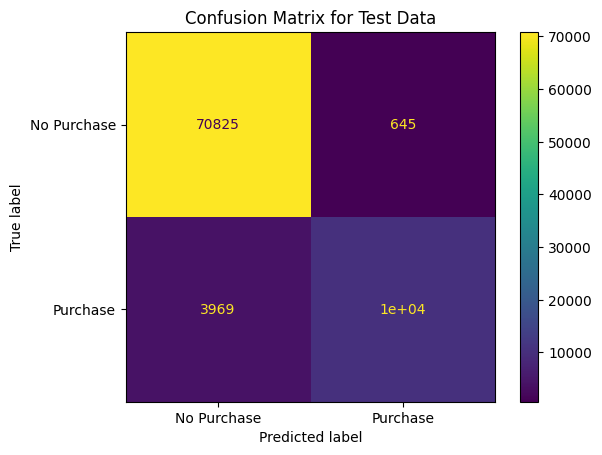

In [30]:
PURCHASE = "Purchase"
NO_PURCHASE = "No Purchase"
LABELS = [NO_PURCHASE, PURCHASE]

probability_threshold = 0.5

predictions = model.predict(x=X_test_scaled) > probability_threshold
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=LABELS)
disp.plot()
plt.title("Confusion Matrix for Test Data")
plt.show()

In [31]:
print("\nClassification Report:")
print(classification_report(y_test.values, predictions, target_names=LABELS))



Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.95      0.99      0.97     71470
    Purchase       0.94      0.72      0.82     14294

    accuracy                           0.95     85764
   macro avg       0.94      0.86      0.89     85764
weighted avg       0.95      0.95      0.94     85764



In [32]:
# Manual calculation for clarity
true_neg, false_pos, false_neg, true_pos = cm.ravel()
precision = true_pos / (true_pos + false_pos)
recall = true_pos / (true_pos + false_neg)


print(f"  True Negatives:  {true_neg:,} (correctly predicted no purchase)")
print(f"  False Positives: {false_pos:,} (predicted purchase, but didn't buy)")
print(f"  False Negatives: {false_neg:,} (predicted no purchase, but did buy)")
print(f"  True Positives:  {true_pos:,} (correctly predicted purchase)")
print(f"\n")
print(f"  Precision: {precision:.2%} (of {(true_pos + false_pos):,} predicted purchases, how many were correct)")
print(f"  Recall:    {recall:.2%} (of {(true_pos + false_neg):,} actual purchases, how many did we catch)")

  True Negatives:  70,825 (correctly predicted no purchase)
  False Positives: 645 (predicted purchase, but didn't buy)
  False Negatives: 3,969 (predicted no purchase, but did buy)
  True Positives:  10,325 (correctly predicted purchase)


  Precision: 94.12% (of 10,970 predicted purchases, how many were correct)
  Recall:    72.23% (of 14,294 actual purchases, how many did we catch)
